# Advanced Neural Network Engineering with PyTorch

> **A comprehensive, production-grade course for advanced AI engineers and researchers.**

---

**Prerequisites:** Solid understanding of calculus, linear algebra, probability theory, and introductory deep learning. Familiarity with Python and basic PyTorch.

**What You Will Master:** This course does not hand-hold. It dissects the *mechanics* of modern neural network training — from memory-efficient data pipelines to advanced optimization theory — equipping you to engineer, debug, and scale production-grade models.

---

## Course Structure

| Module | Topic | Core Focus |
|--------|-------|------------|
| 1 | The PyTorch Data Pipeline | Custom Datasets, optimized DataLoaders, memory management |
| 2 | Architecture & Signal Propagation | Activation functions, BatchNorm, LayerNorm |
| 3 | The Training Engine | Loss functions, optimizers, backpropagation, training loop |
| 4 | Advanced Optimization & Stability | AdamW, scheduling, gradient clipping |
| 5 | Generalization & Regularization | Dropout, weight decay, stochastic depth, early stopping |
| 6 | Diagnostics & Performance Tuning | Metrics, debugging, validation strategy |
| 7 | Advanced Learning Paradigms | Transfer learning, pretraining, auxiliary tasks |

---

## Setup & Dependencies

In [2]:
# Environment setup
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install torchmetrics matplotlib seaborn tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Dict, Optional, List, Callable, Any
import time
import os
import math
import copy
from pathlib import Path
from dataclasses import dataclass, field
import warnings
warnings.filterwarnings('ignore')

# Reproducibility — always pin your seeds in research
def seed_everything(seed: int = 42):
    """Pin all sources of randomness for reproducible experiments."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False   # True = faster but non-deterministic

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Active device   : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
Active device   : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


---

# Module 1: The PyTorch Data Pipeline

> *"Garbage in, garbage out. A model is only as good as the data it sees — and how fast it sees it."*

---

## 1.1 Theoretical Breakdown

### Why the Data Pipeline is a First-Class Concern

Training throughput is fundamentally bounded by whichever component is slowest: GPU computation or data I/O. In modern deep learning, the GPU is almost always the faster component — which means a poorly engineered data pipeline **starves the GPU**, reducing expensive hardware to idle cycles.

The key insight: **the data pipeline runs concurrently with GPU computation**. While the GPU processes batch $t$, the CPU should be loading and preprocessing batch $t+1$. If the CPU is not ready, the GPU blocks. This is the prefetching problem.

### The `Dataset` / `DataLoader` Contract

PyTorch enforces a clean separation of concerns:

- **`Dataset`**: Knows *what* the data is. Implements `__len__` and `__getitem__`.
- **`DataLoader`**: Knows *how* to serve the data. Handles batching, shuffling, and parallel loading.

### Memory Management Strategies

**On-disk vs. In-memory loading:**
- Small datasets: Load everything into RAM at init time — zero I/O overhead during training.
- Large datasets: Stream from disk using `__getitem__`. Risk: repeated, redundant disk reads.
- Hybrid: Use memory-mapped files (`numpy.memmap`, HDF5, LMDB) for near-RAM speeds from disk.

**Pinned Memory:**  
By default, CPU tensors are in pageable memory. The CUDA DMA engine cannot directly read pageable memory — it must first copy to a temporary pinned (page-locked) buffer. Setting `pin_memory=True` in the DataLoader allocates tensors directly in pinned memory, eliminating one copy hop. `.to(device, non_blocking=True)` then transfers asynchronously, overlapping with computation.

**Worker Processes:**  
DataLoader spawns `num_workers` *separate processes* (not threads — Python's GIL is irrelevant here). Each worker independently calls `__getitem__`. The main process collates results via a multiprocessing queue. Optimal `num_workers` is typically `2 × num_CPU_cores`, but must be tuned empirically as it depends on I/O vs. compute balance.

**`persistent_workers=True`:** Prevents worker process teardown/respawn between epochs — critical when worker startup time (model loading, file handles) is significant.

In [3]:
# =============================================================================
# MODULE 1: THE PYTORCH DATA PIPELINE
# =============================================================================

# ── 1A: Baseline Dataset (on-disk pattern) ───────────────────────────────────

class ImageDataset(Dataset):
    """
    Production-grade Dataset for image data stored on disk.
    
    Design decisions:
      - Caching flag for small datasets: trades RAM for I/O speed.
      - Accepts arbitrary callable transforms: decoupled preprocessing.
      - Validates file paths at init: fail fast, not during training.
    """
    def __init__(
        self,
        file_paths: List[str],
        labels: List[int],
        transform: Optional[Callable] = None,
        cache_in_memory: bool = False,
    ):
        assert len(file_paths) == len(labels), "Paths and labels must be same length."
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        self.cache_in_memory = cache_in_memory
        self._cache: Dict[int, torch.Tensor] = {}

    def __len__(self) -> int:
        return len(self.file_paths)

    def _load_sample(self, idx: int) -> torch.Tensor:
        """Load a single sample. Override this for different data formats."""
        # Stub: in production, use PIL.Image.open() or cv2.imread()
        # Here we simulate with random data
        return torch.randn(3, 224, 224)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        # Cache hit: return immediately
        if self.cache_in_memory and idx in self._cache:
            sample = self._cache[idx]
        else:
            sample = self._load_sample(idx)
            if self.cache_in_memory:
                self._cache[idx] = sample  # store raw tensor

        if self.transform:
            sample = self.transform(sample)

        label = self.labels[idx]
        return sample, label


# ── 1B: Memory-Mapped Dataset for large-scale data ───────────────────────────

class MemoryMappedDataset(Dataset):
    """
    Efficient dataset using numpy memmap for large arrays that don't fit in RAM.
    
    memmap creates a disk-backed array: the OS loads only the requested
    pages into RAM on access. Near-zero startup overhead, O(batch_size) memory.
    """
    def __init__(self, data_path: str, label_path: str, shape: tuple, dtype=np.float32):
        # mmap opens a file-backed array — no data is loaded yet
        self.data   = np.memmap(data_path,   dtype=dtype, mode='r', shape=shape)
        self.labels = np.memmap(label_path,  dtype=np.int64, mode='r', shape=(shape[0],))

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # np.array() creates an actual copy from the mapped region — necessary
        # because torch.from_numpy() requires contiguous writable memory.
        x = torch.from_numpy(np.array(self.data[idx]))   # shape: (C, H, W)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


# ── 1C: Optimized DataLoader Configuration ───────────────────────────────────

def build_dataloader(
    dataset: Dataset,
    batch_size: int,
    is_train: bool,
    num_workers: int = 4,
) -> DataLoader:
    """
    Factory function for production-grade DataLoader configuration.
    
    Key parameters:
      pin_memory       : Allocates batches in pinned (page-locked) CPU memory,
                         enabling asynchronous DMA transfers to GPU.
      persistent_workers: Keeps worker processes alive across epochs.
                         Prevents ~0.5-1s spawn overhead per epoch.
      prefetch_factor  : Each worker prefetches this many batches ahead.
                         Set to 2 (default) — higher values waste RAM.
      drop_last        : Drop incomplete final batch during training.
                         Prevents BatchNorm statistics instability on tiny batches.
    """
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,               # Never shuffle validation/test
        num_workers=num_workers,
        pin_memory=True,                # Essential for GPU training
        persistent_workers=(num_workers > 0),
        prefetch_factor=2 if num_workers > 0 else None,
        drop_last=is_train,
    )


# ── 1D: Custom Collate Function ───────────────────────────────────────────────

def variable_length_collate(batch: List[Tuple]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Custom collate for variable-length sequences (e.g., NLP, time-series).
    
    Default collate_fn assumes all items in a batch are same shape.
    This pads sequences to the max length in the batch (dynamic padding),
    which is more efficient than global max-length padding.
    """
    sequences, labels = zip(*batch)

    lengths = torch.tensor([s.shape[0] for s in sequences], dtype=torch.long)
    max_len = lengths.max().item()

    # Pad all sequences to max_len with zeros
    padded = torch.zeros(len(sequences), max_len, sequences[0].shape[-1])
    for i, seq in enumerate(sequences):
        padded[i, :seq.shape[0]] = seq

    return padded, lengths, torch.tensor(labels, dtype=torch.long)


# ── 1E: Benchmark — measure throughput ───────────────────────────────────────

def benchmark_dataloader(loader: DataLoader, n_batches: int = 50) -> float:
    """Measure DataLoader throughput in samples/sec."""
    total_samples = 0
    t0 = time.perf_counter()
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        x = x.to(DEVICE, non_blocking=True)  # async transfer
        total_samples += x.shape[0]
    elapsed = time.perf_counter() - t0
    throughput = total_samples / elapsed
    return throughput


# ── Demo ──────────────────────────────────────────────────────────────────────

N = 1000
dummy_paths  = [f"img_{i}.jpg" for i in range(N)]
dummy_labels = list(np.random.randint(0, 10, N))
dataset = ImageDataset(dummy_paths, dummy_labels)

train_size = int(0.8 * N)
train_ds, val_ds = random_split(dataset, [train_size, N - train_size])

train_loader = build_dataloader(train_ds, batch_size=32, is_train=True,  num_workers=0)
val_loader   = build_dataloader(val_ds,   batch_size=64, is_train=False, num_workers=0)

x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape : {x_batch.shape}   (B, C, H, W)")
print(f"Label shape : {y_batch.shape}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Batch shape : torch.Size([32, 3, 224, 224])   (B, C, H, W)
Label shape : torch.Size([32])
Train batches: 25 | Val batches: 4


## 1.2 Engineering Best Practices — Module 1

| Issue | Symptom | Fix |
|-------|---------|-----|
| **GPU starvation** | GPU utilization < 80% (check `nvidia-smi`) | Increase `num_workers`, enable `pin_memory`, use `persistent_workers` |
| **DataLoader deadlock** | Training hangs at epoch start | Set `num_workers=0` to debug; common with `fork` on macOS — use `spawn` |
| **OOM during loading** | CUDA out of memory on batch transfer | Reduce `batch_size` or `prefetch_factor`; ensure tensors are not accumulated |
| **Slow transforms** | CPU bottleneck in `__getitem__` | Move heavy augmentation to GPU (e.g., `torchvision.transforms.v2`) |
| **BatchNorm instability** | Loss spikes at epoch end | Use `drop_last=True` to avoid micro-batches of size 1-2 |
| **Shuffle leakage** | Train/val overlap distorting metrics | Use `random_split` with fixed generator, not index slicing |

```python
# CORRECT: reproducible split
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(dataset, [0.8, 0.2], generator=generator)

# WRONG: index slicing can leak if dataset isn't shuffled
train_ds = dataset[:800]  # DON'T do this
```

---

# Module 2: Architecture & Signal Propagation

> *"A neural network is an information channel. Your job is to keep that channel open — neither saturated nor dead."*

---

## 2.1 Theoretical Breakdown

### Activation Functions: The Non-Linear Heart of Deep Learning

Without non-linear activations, any stack of linear layers collapses to a single linear transformation. Activations introduce the expressive capacity that allows networks to approximate arbitrary functions (Universal Approximation Theorem). But the *choice* of activation critically impacts gradient flow.

**Vanishing Gradient Problem:**  
In backpropagation, gradients are multiplied through the chain rule across every layer:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(L)}} \cdot \prod_{l=2}^{L} \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{a}^{(l-1)}}$$

If each activation derivative $< 1$, this product shrinks exponentially with depth — early layers receive near-zero gradients and stop learning.

**Key Activations:**

| Activation | Formula | Gradient | Problem |
|-----------|---------|----------|----------|
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(1-\sigma) \leq 0.25$ | Saturates; vanishing gradients |
| Tanh | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $1 - \tanh^2 \leq 1$ | Saturates; vanishing gradients |
| ReLU | $\max(0, x)$ | $\mathbf{1}[x > 0]$ | Dead neurons ($x < 0$ always) |
| Leaky ReLU | $\max(\alpha x, x)$ | $\alpha$ if $x < 0$, else $1$ | Fixes dead neurons |
| GELU | $x \cdot \Phi(x)$ | Smooth, non-monotone | None — state-of-art for transformers |
| Swish | $x \cdot \sigma(\beta x)$ | Smooth, self-gated | Slightly more compute |
| Mish | $x \cdot \tanh(\text{softplus}(x))$ | Smooth, bounded below | More compute |

**GELU** (Gaussian Error Linear Unit):
$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

GELU stochastically gates inputs based on their magnitude — large positives pass, large negatives are dropped, near-zero inputs are stochastically gated. This regularization effect is why it outperforms ReLU in attention-based architectures.

### Internal Covariate Shift and Normalization

**Internal Covariate Shift (ICS):** As weights update during training, the distribution of each layer's inputs shifts. Deeper layers must continuously adapt to changing input statistics — this slows convergence and requires lower learning rates.

**Batch Normalization** normalizes the pre-activation output $\mathbf{z}^{(l)}$ within each mini-batch:
$$\hat{z}_i = \frac{z_i - \mu_\mathcal{B}}{\sqrt{\sigma^2_\mathcal{B} + \epsilon}}$$
$$\text{BN}(z_i) = \gamma \hat{z}_i + \beta$$

where $\mu_\mathcal{B}$ and $\sigma^2_\mathcal{B}$ are the batch mean and variance. $\gamma, \beta$ are learnable parameters that restore representational capacity (the network can undo normalization if optimal).

**At inference:** BN uses running statistics accumulated during training (exponential moving average), not batch statistics — this is why `model.eval()` is mandatory.

**Layer Normalization** normalizes across the *feature* dimension, not the batch:
$$\text{LN}(\mathbf{x}) = \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta$$

where $\mu, \sigma$ are computed over the feature vector of a *single* sample. This makes LN batch-size independent — essential for transformers with variable-length sequences, recurrent networks, and small-batch scenarios.

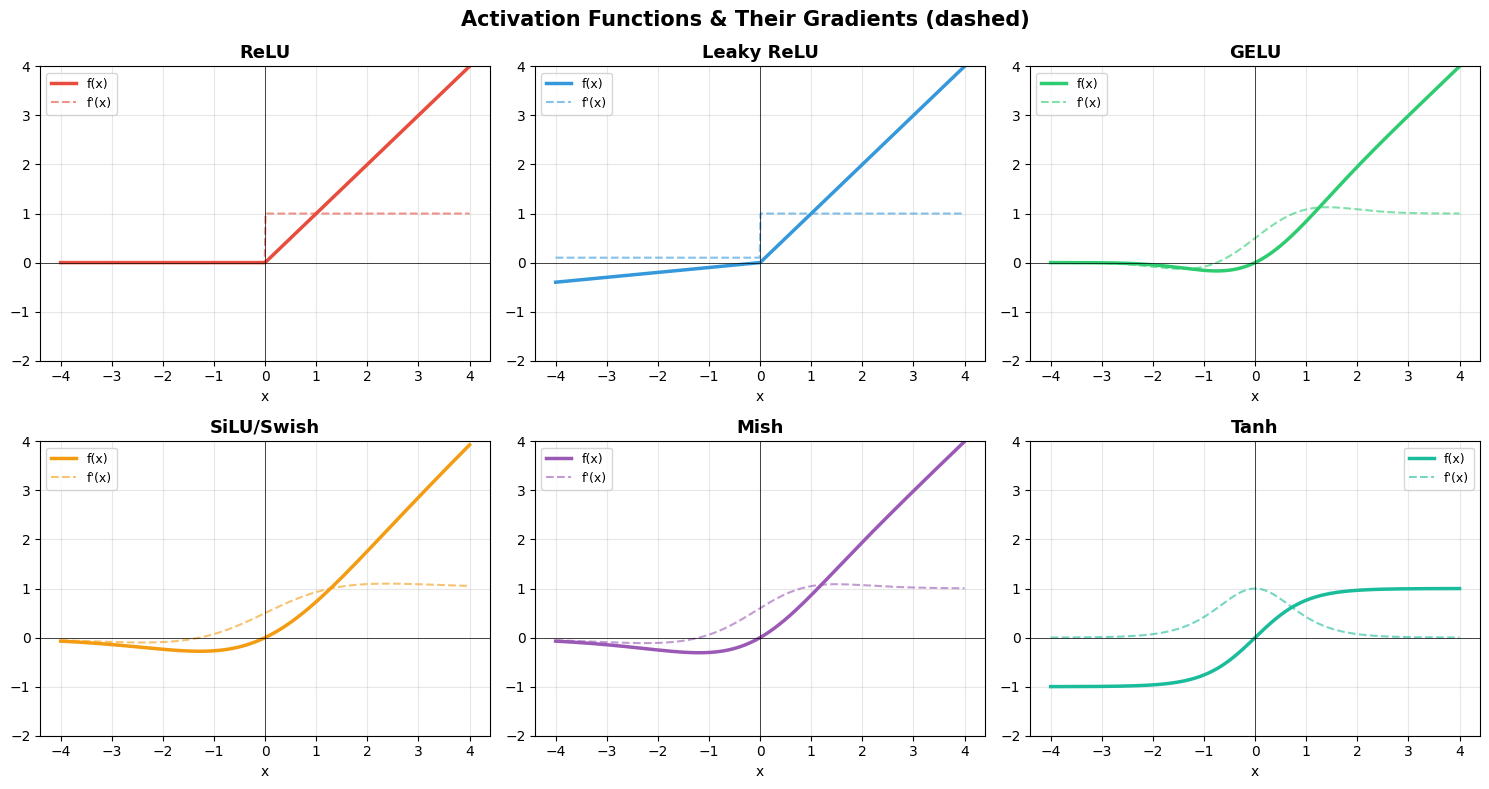

Key observation: ReLU gradient is binary (0 or 1) — dead neuron risk.
GELU/SiLU have smooth, non-zero gradients everywhere — better gradient flow.


In [4]:
# =============================================================================
# MODULE 2: ARCHITECTURE & SIGNAL PROPAGATION
# =============================================================================

# ── 2A: Activation Function Implementations ───────────────────────────────────

class Activations:
    """Reference implementations of modern activation functions."""

    @staticmethod
    def gelu(x: torch.Tensor, approximate: str = 'tanh') -> torch.Tensor:
        """
        GELU: x * Φ(x) where Φ is the Gaussian CDF.
        'tanh' approximation is used in GPT/BERT for ~15% speedup:
          GELU(x) ≈ 0.5x(1 + tanh(sqrt(2/π) * (x + 0.044715x³)))
        """
        return F.gelu(x, approximate=approximate)

    @staticmethod
    def swish(x: torch.Tensor, beta: float = 1.0) -> torch.Tensor:
        """Swish: x * sigmoid(β*x). β=1 is default (EfficientNet uses this)."""
        return x * torch.sigmoid(beta * x)

    @staticmethod
    def mish(x: torch.Tensor) -> torch.Tensor:
        """Mish: x * tanh(softplus(x)). Strong in YOLO/detection models."""
        return x * torch.tanh(F.softplus(x))

    @staticmethod
    def silu(x: torch.Tensor) -> torch.Tensor:
        """SiLU = Swish-1 = x * sigmoid(x). Native PyTorch support."""
        return F.silu(x)


# ── 2B: Visualizing Activations & Their Gradients ────────────────────────────

x = torch.linspace(-4, 4, 500, requires_grad=True)
activations_dict = {
    'ReLU':       F.relu(x),
    'Leaky ReLU': F.leaky_relu(x, 0.1),
    'GELU':       F.gelu(x),
    'SiLU/Swish': F.silu(x),
    'Mish':       Activations.mish(x),
    'Tanh':       torch.tanh(x),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

for ax, (name, out), color in zip(axes, activations_dict.items(), colors):
    # Compute gradient via autograd
    if x.grad is not None:
        x.grad.zero_()
    out.sum().backward(retain_graph=True)
    grad = x.grad.detach().numpy()
    x_np = x.detach().numpy()

    ax.plot(x_np, out.detach().numpy(), color=color, lw=2.5, label='f(x)')
    ax.plot(x_np, grad, color=color, lw=1.5, ls='--', alpha=0.6, label="f'(x)")
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-2, 4)
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions & Their Gradients (dashed)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("Key observation: ReLU gradient is binary (0 or 1) — dead neuron risk.")
print("GELU/SiLU have smooth, non-zero gradients everywhere — better gradient flow.")

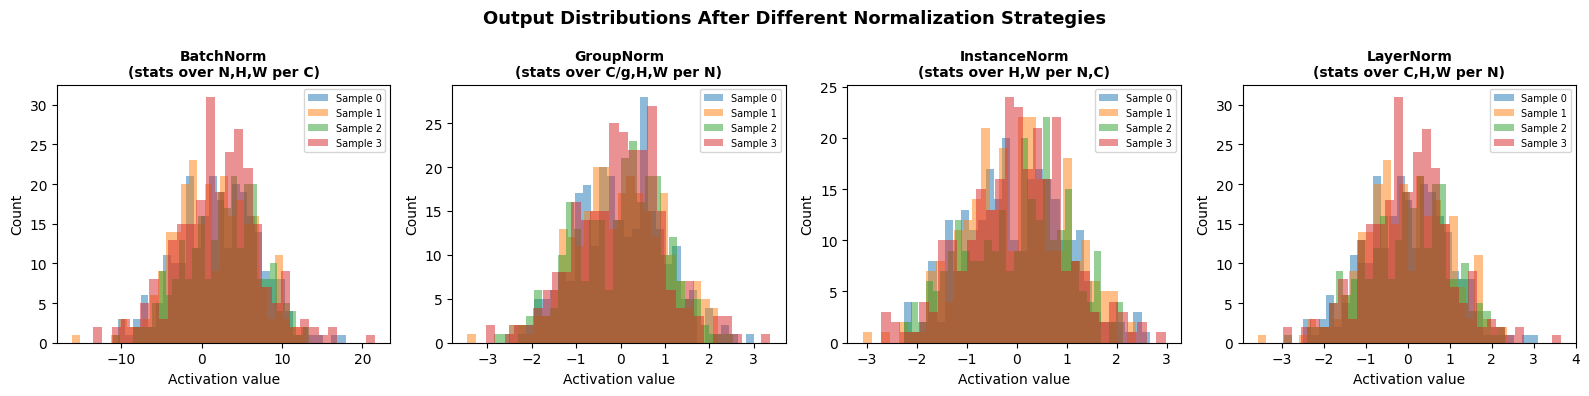

ResidualBlock: (2, 64, 32, 32) → (2, 128, 16, 16)
Parameters: 229,760


In [5]:
# ── 2C: Normalization Layers — Implementation & Comparison ───────────────────

class NormalizationDemo(nn.Module):
    """
    Demonstrates BatchNorm vs LayerNorm on identical inputs.
    
    BatchNorm statistics axes: (N, H, W) → normalized per channel C
    LayerNorm statistics axes: (C, H, W) → normalized per sample N
    """
    def __init__(self, num_features: int, norm_type: str = 'batch'):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == 'batch':
            # momentum: EMA coefficient for running stats (default 0.1)
            # affine: learnable gamma and beta (always True in practice)
            # track_running_stats: maintains EMA for inference
            self.norm = nn.BatchNorm2d(
                num_features,
                eps=1e-5,
                momentum=0.1,
                affine=True,
                track_running_stats=True,
            )
        elif norm_type == 'layer':
            # normalized_shape: dimensions to normalize over
            # For 2D conv features (B, C, H, W) → normalize over C,H,W
            self.norm = nn.LayerNorm(num_features, eps=1e-5)
        elif norm_type == 'group':
            # GroupNorm: divides channels into groups, normalizes within each
            # Compromise between BN and LN; works well with small batches
            self.norm = nn.GroupNorm(num_groups=8, num_channels=num_features, eps=1e-5)
        elif norm_type == 'instance':
            # InstanceNorm: normalizes each channel of each sample independently
            # Used in style transfer; batch-size independent like LN
            self.norm = nn.InstanceNorm2d(num_features, eps=1e-5, affine=True)
        else:
            raise ValueError(f"Unknown norm type: {norm_type}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x)


# Visualize normalization behavior
B, C, H, W = 8, 16, 4, 4
x_norm = torch.randn(B, C, H, W) * 5 + 2  # non-zero mean, large variance

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
norm_types = ['batch', 'group', 'instance', 'layer']
titles = ['BatchNorm\n(stats over N,H,W per C)', 
          'GroupNorm\n(stats over C/g,H,W per N)',
          'InstanceNorm\n(stats over H,W per N,C)',
          'LayerNorm\n(stats over C,H,W per N)']

for ax, norm_type, title in zip(axes, norm_types, titles):
    model_norm = NormalizationDemo(C if norm_type != 'layer' else C*H*W, 
                                   norm_type).eval()
    with torch.no_grad():
        if norm_type == 'layer':
            # LayerNorm expects (B, ...) where ... are the normalized dims
            x_flat = x_norm.view(B, -1)  # (B, C*H*W)
            out = model_norm(x_flat).view(B, C, H, W)
        else:
            out = model_norm(x_norm)
    
    # Show distribution of output values for first 4 samples
    for i in range(4):
        ax.hist(out[i].numpy().flatten(), bins=30, alpha=0.5, label=f'Sample {i}')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Activation value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Output Distributions After Different Normalization Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── 2D: ResNet-style Block with proper normalization placement ────────────────

class ResidualBlock(nn.Module):
    """
    Pre-activation ResNet block (He et al., 2016 - Identity Mappings).
    
    Pre-activation order: BN → ReLU → Conv
    Advantages over original (Conv → BN → ReLU):
      1. Gradient flows directly through the skip connection (identity path)
      2. Better regularization effect from BN before activation
      3. Enables training of 1000+ layer networks
    """
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        # Pre-activation path: BN → activation → conv
        self.bn1   = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)

        # Projection shortcut: when dimensions change, we must project
        # the residual to match (downsample = identity otherwise)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-activation pattern
        out = self.conv1(F.gelu(self.bn1(x)))   # GELU instead of ReLU — modern choice
        out = self.conv2(F.gelu(self.bn2(out)))
        # Skip connection: f(x) + x — the key that makes deep networks trainable
        return out + self.shortcut(x)


# Quick sanity check — shapes propagate correctly
block = ResidualBlock(64, 128, stride=2)
test_in = torch.randn(2, 64, 32, 32)
test_out = block(test_in)
print(f"ResidualBlock: {tuple(test_in.shape)} → {tuple(test_out.shape)}")
print(f"Parameters: {sum(p.numel() for p in block.parameters()):,}")

## 2.2 Engineering Best Practices — Module 2

| Issue | Root Cause | Fix |
|-------|-----------|-----|
| **Dead ReLU neurons** | Bias init or large LR drives pre-activations permanently negative | Switch to Leaky ReLU / GELU; use smaller init; use LR warmup |
| **BN breaks at inference** | Forgot `model.eval()` | Always call `model.eval()` and `torch.no_grad()` during validation/inference |
| **BN with batch_size=1** | Variance = 0, division by epsilon only | Use GroupNorm or LayerNorm for small batches |
| **Conv + BN: redundant bias** | BN subtracts mean, making additive bias useless | Always set `bias=False` in Conv layers followed by BN |
| **Wrong norm for Transformers** | BN depends on batch axis; sequences have variable length | Use LayerNorm — standard for all attention-based architectures |

---

# Module 3: The Training Engine (Core Mechanics)

> *"The optimizer is not magic. It is a deterministic algorithm executing the instructions that your loss function encodes."*

---

## 3.1 Theoretical Breakdown

### Loss Functions: Encoding the Learning Objective

The loss function $\mathcal{L}$ is the *only* channel through which the network receives information about what it's supposed to learn. Every architectural and optimization decision is downstream of this choice.

**Cross-Entropy Loss (Classification):**
$$\mathcal{L}_{CE} = -\sum_{c=1}^{C} y_c \log(\hat{p}_c) = -\log(\hat{p}_{y^*})$$

For multi-class, this reduces to the negative log-probability of the true class. PyTorch's `nn.CrossEntropyLoss` combines `LogSoftmax + NLLLoss` in a numerically stable single operation — **never** apply softmax before this loss.

**Label Smoothing** — a regularization technique:
$$y_c^{LS} = y_c(1-\epsilon) + \frac{\epsilon}{C}$$

Prevents the network from becoming overconfident. Used in SOTA classifiers. Available via `label_smoothing` parameter in `nn.CrossEntropyLoss`.

**MSE vs MAE (Regression):**
- **MSE** ($\ell_2$): $\mathcal{L} = \frac{1}{N}\sum(y - \hat{y})^2$ — penalizes outliers heavily (squared), fast convergence near optimum
- **MAE** ($\ell_1$): $\mathcal{L} = \frac{1}{N}\sum|y - \hat{y}|$ — robust to outliers, but gradient discontinuity at 0
- **Huber Loss**: Combines both — $\ell_2$ for small errors, $\ell_1$ for large errors

### Backpropagation: The Math

Backpropagation is the efficient application of the **chain rule** to compute $\nabla_{\mathbf{W}} \mathcal{L}$ for all parameters simultaneously.

For a single neuron: $z = \mathbf{w}^T \mathbf{x} + b$, $a = \sigma(z)$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = \delta \cdot \sigma'(z) \cdot \mathbf{x}$$

where $\delta$ is the **error signal** (gradient) flowing from the layer above. PyTorch's autograd engine builds a **dynamic computational graph** during the forward pass and traverses it in reverse via topological sort during `.backward()`.

### SGD and the Learning Rate

Vanilla Gradient Descent:
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla_{\mathbf{w}} \mathcal{L}$$

**SGD with Momentum:**
$$\mathbf{v}_{t+1} = \mu \mathbf{v}_t - \eta \nabla_{\mathbf{w}} \mathcal{L}$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t + \mathbf{v}_{t+1}$$

Momentum $\mu$ (typically 0.9) accumulates an exponential moving average of gradients. This dampens oscillations in high-curvature directions and accelerates progress in low-curvature directions.

**Adam Optimizer:**
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(1st moment / EMA of gradient)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(2nd moment / EMA of squared gradient)}$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \quad \text{(bias correction)}$$
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Adam adapts the learning rate per-parameter using the ratio of first to second moments — effectively a **signal-to-noise** ratio of the gradient.

In [6]:
# =============================================================================
# MODULE 3: THE TRAINING ENGINE (CORE MECHANICS)
# =============================================================================

# ── 3A: Loss Function Gallery ─────────────────────────────────────────────────

class LossFunctionGallery:
    """
    Production-ready loss functions with correct usage patterns.
    Each function shows the correct input format — a frequent source of bugs.
    """

    @staticmethod
    def cross_entropy_with_smoothing(num_classes: int, smoothing: float = 0.1) -> nn.CrossEntropyLoss:
        """
        Input:  logits of shape (N, C) — raw scores, NO softmax!
        Target: class indices of shape (N,) — dtype=torch.long
        """
        return nn.CrossEntropyLoss(label_smoothing=smoothing)

    @staticmethod
    def focal_loss(gamma: float = 2.0, alpha: Optional[torch.Tensor] = None) -> Callable:
        """
        Focal Loss (Lin et al., 2017) for class imbalance.
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
        
        The (1-p_t)^gamma term down-weights easy examples,
        focusing training on hard misclassified examples.
        """
        def focal(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
            ce_loss = F.cross_entropy(logits, targets, weight=alpha, reduction='none')
            pt = torch.exp(-ce_loss)           # p_t: probability of correct class
            focal_weight = (1 - pt) ** gamma   # down-weight well-classified examples
            return (focal_weight * ce_loss).mean()
        return focal

    @staticmethod
    def dice_loss(smooth: float = 1.0) -> Callable:
        """
        Dice Loss for segmentation. Measures overlap between prediction and ground truth.
        Dice = 2|A∩B| / (|A| + |B|)  →  Loss = 1 - Dice
        Handles class imbalance naturally — insensitive to background dominance.
        """
        def dice(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
            pred = torch.sigmoid(pred).view(-1)   # Binary predictions after sigmoid
            target = target.view(-1).float()
            intersection = (pred * target).sum()
            return 1 - (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return dice

    @staticmethod
    def contrastive_loss(temperature: float = 0.07) -> Callable:
        """
        InfoNCE / NT-Xent loss for self-supervised contrastive learning (SimCLR, CLIP).
        Maximizes agreement between positive pairs, minimizes with negatives.
        """
        def contrastive(z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
            # L2 normalize embeddings to unit sphere
            z1 = F.normalize(z1, dim=-1)
            z2 = F.normalize(z2, dim=-1)
            N = z1.shape[0]
            # Similarity matrix: (2N, 2N)
            z = torch.cat([z1, z2], dim=0)
            sim = torch.mm(z, z.T) / temperature  # cosine similarity / temperature
            # Remove self-similarity (diagonal)
            mask = torch.eye(2*N, dtype=torch.bool, device=z.device)
            sim.masked_fill_(mask, -1e9)
            # Positive pairs: (i, i+N) and (i+N, i)
            labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)
            return F.cross_entropy(sim, labels)
        return contrastive


# ── 3B: Model for Training Loop Demo ─────────────────────────────────────────

class ConvClassifier(nn.Module):
    """Simple but production-patterned CNN for classification."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        """Kaiming (He) initialization for ReLU/GELU-family activations."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # mode='fan_out' preserves variance in the forward pass
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)  # gamma = 1
                nn.init.constant_(m.bias, 0)    # beta  = 0
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# ── 3C: The Production Training Loop ─────────────────────────────────────────

@dataclass
class TrainConfig:
    """Centralized training configuration. Single source of truth."""
    num_epochs:     int   = 20
    batch_size:     int   = 32
    lr:             float = 1e-3
    weight_decay:   float = 1e-4
    grad_clip:      float = 1.0
    label_smoothing: float = 0.1
    num_workers:    int   = 0
    num_classes:    int   = 10
    log_every:      int   = 10   # log every N batches


class Trainer:
    """
    Clean, extensible training engine.
    
    Design principles:
      - State is explicit: stored in self.history for later analysis
      - Separation of train_epoch / evaluate: testable independently
      - Gradient clipping integrated: prevents explosions silently
      - AMP (Automatic Mixed Precision) ready: ~2x speedup on modern GPUs
    """
    def __init__(self, model: nn.Module, config: TrainConfig, device: torch.device):
        self.model  = model.to(device)
        self.cfg    = config
        self.device = device

        self.criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=config.lr,
            weight_decay=config.weight_decay,
            betas=(0.9, 0.999),
        )
        # AMP GradScaler: prevents gradient underflow in fp16
        self.scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

        self.history: Dict[str, List[float]] = {
            'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []
        }

    def train_epoch(self, loader: DataLoader) -> Tuple[float, float]:
        self.model.train()  # CRITICAL: enables dropout, BN uses batch stats
        total_loss, correct, total = 0.0, 0, 0

        for batch_idx, (x, y) in enumerate(loader):
            x = x.to(self.device, non_blocking=True)
            y = y.to(self.device, non_blocking=True)

            # ── Forward pass with Automatic Mixed Precision ──
            with torch.amp.autocast('cuda', enabled=(self.device.type == 'cuda')):
                logits = self.model(x)
                loss   = self.criterion(logits, y)

            # ── Backward pass ────────────────────────────────
            self.optimizer.zero_grad(set_to_none=True)  # set_to_none saves a memset
            self.scaler.scale(loss).backward()          # scaled backward for AMP

            # ── Gradient clipping ────────────────────────────
            # Must unscale before clipping (AMP requirement)
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)

            # ── Optimizer step ───────────────────────────────
            self.scaler.step(self.optimizer)   # skips update if grads are inf/nan
            self.scaler.update()               # adjusts scale for next iteration

            # ── Metrics ──────────────────────────────────────
            total_loss += loss.item()
            preds       = logits.argmax(dim=1)
            correct    += preds.eq(y).sum().item()
            total      += y.size(0)

        return total_loss / len(loader), correct / total

    @torch.no_grad()  # Decorator form — disable autograd for entire method
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        self.model.eval()   # CRITICAL: disables dropout, BN uses running stats
        total_loss, correct, total = 0.0, 0, 0

        for x, y in loader:
            x = x.to(self.device, non_blocking=True)
            y = y.to(self.device, non_blocking=True)
            logits = self.model(x)
            loss   = self.criterion(logits, y)
            total_loss += loss.item()
            correct    += logits.argmax(1).eq(y).sum().item()
            total      += y.size(0)

        return total_loss / len(loader), correct / total

    def fit(self, train_loader: DataLoader, val_loader: DataLoader):
        """Main training loop. Returns self for chaining."""
        print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
        print("-" * 55)

        for epoch in range(1, self.cfg.num_epochs + 1):
            t_loss, t_acc = self.train_epoch(train_loader)
            v_loss, v_acc = self.evaluate(val_loader)

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['train_acc'].append(t_acc)
            self.history['val_acc'].append(v_acc)

            if epoch % self.cfg.log_every == 0 or epoch == 1:
                print(f"{epoch:>6} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>7.4f}")

        return self


# Quick demo with synthetic data
cfg = TrainConfig(num_epochs=5, batch_size=32, log_every=1)
model = ConvClassifier(num_classes=10)
trainer = Trainer(model, cfg, DEVICE)

# Synthetic loaders
synth_train = DataLoader(
    [(torch.randn(3, 32, 32), torch.randint(0, 10, ())) for _ in range(320)],
    batch_size=32, shuffle=True
)
synth_val = DataLoader(
    [(torch.randn(3, 32, 32), torch.randint(0, 10, ())) for _ in range(128)],
    batch_size=64
)

trainer.fit(synth_train, synth_val)
print("\n✓ Training complete.")

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
     1 |     2.3788 |    0.1031 |   2.3056 |  0.0781
     2 |     2.1782 |    0.2500 |   2.3077 |  0.1016
     3 |     2.1053 |    0.3125 |   2.3273 |  0.0703
     4 |     2.0012 |    0.4500 |   2.3517 |  0.0547
     5 |     1.9100 |    0.5000 |   2.3514 |  0.0625

✓ Training complete.


## 3.2 Engineering Best Practices — Module 3

| Issue | Root Cause | Fix |
|-------|-----------|-----|
| **NaN loss immediately** | Exploding gradients, bad init, or inf in data | Check data for NaN/Inf; use gradient clipping; use AMP with `GradScaler` |
| **`zero_grad()` vs `zero_grad(set_to_none=True)`** | Default sets to 0-tensor (wastes memory) | Use `set_to_none=True` — `None` means no tensor allocated at all |
| **Softmax before CrossEntropyLoss** | Double-softmax crushes gradients | Feed raw logits to `nn.CrossEntropyLoss` — it applies log-softmax internally |
| **Wrong model mode** | `model.train()` during eval inflates train accuracy via dropout | Always `model.eval()` for inference; `model.train()` before each train loop |
| **Memory leak across epochs** | Storing `loss` (a tensor with attached graph) in a list | Always `.item()` to detach: `history.append(loss.item())` |

---

# Module 4: Advanced Optimization & Stability

> *"Choosing the wrong optimizer is like choosing the wrong map. You'll move confidently — in the wrong direction."*

---

## 4.1 Theoretical Breakdown

### AdamW: The Correct Weight Decay

**The Adam Weight Decay Bug:**  
Original Adam incorporates weight decay by adding $\lambda \mathbf{w}$ to the gradient before computing moments. This means weight decay is scaled by the adaptive second-moment estimate $\hat{v}_t$ — **coupling regularization with gradient adaptation**. Parameters with large, consistent gradients get less regularization than intended.

**AdamW (Loshchilov & Hutter, 2018)** decouples weight decay:
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta\left(\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon} + \lambda \mathbf{w}_t\right)$$

Weight decay is applied directly to the parameter *after* the adaptive update — making it **truly** equivalent to $\ell_2$ regularization. This is the default optimizer in most modern transformer training pipelines.

### Learning Rate Scheduling

A fixed LR is almost never optimal. The ideal schedule:
1. **Warmup phase**: Start with $\eta_{\min}$, linearly increase to $\eta_{\max}$ over $T_{warmup}$ steps. Prevents large updates early when parameters are far from their optimal distribution.
2. **Decay phase**: Gradually reduce LR to allow fine-grained convergence.

**Cosine Annealing:**
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{T_{cur}}{T_{max}}\pi\right)\right)$$

Smooth decay that avoids the abrupt step-function reductions of StepLR.

**ReduceLROnPlateau**: Patience-based scheduler. Reduces LR by a factor when a monitored metric stops improving. Robust for unknown training dynamics.

### Gradient Clipping

Clips the **global** gradient norm to prevent explosions in RNNs, Transformers, and deep networks:
$$\mathbf{g} \leftarrow \mathbf{g} \cdot \frac{\text{clip\_value}}{\max(\|\mathbf{g}\|_2, \text{clip\_value})}$$

This scales the entire gradient vector uniformly, preserving its *direction* while bounding its *magnitude*. **Value clipping** (`clip_grad_value_`) clips individual elements — less principled, but useful for debugging.

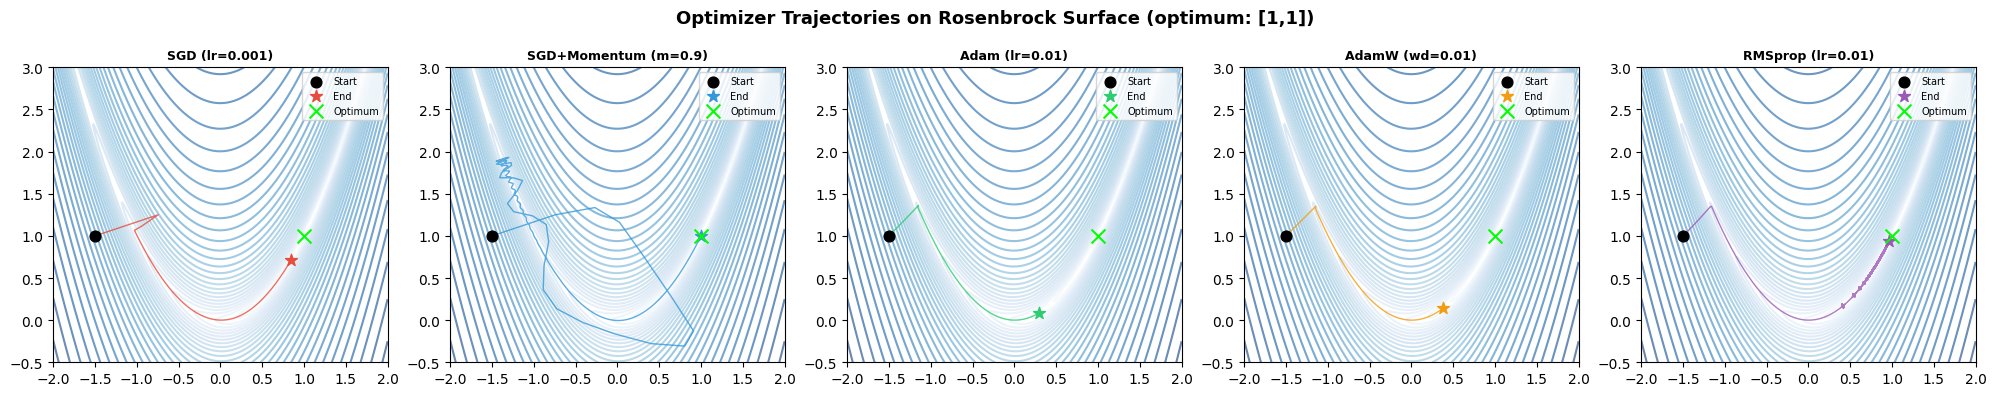

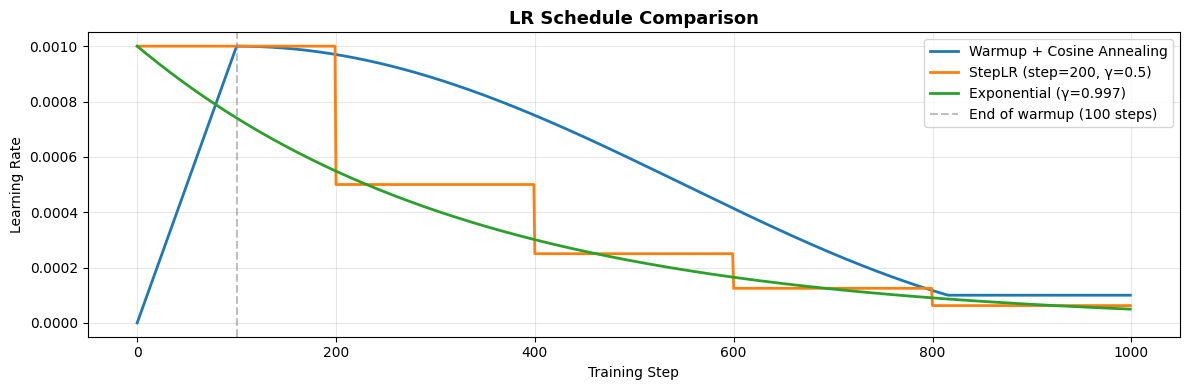


Key insight: Warmup prevents large updates when weights are randomly initialized.
Cosine decay provides smooth convergence without choosing step sizes manually.


In [7]:
# =============================================================================
# MODULE 4: ADVANCED OPTIMIZATION & STABILITY
# =============================================================================

# ── 4A: Warmup + Cosine Annealing Scheduler ───────────────────────────────────

class WarmupCosineScheduler(optim.lr_scheduler.LambdaLR):
    """
    Linear warmup followed by cosine annealing.
    
    This is the de-facto standard for training large models (BERT, GPT, ViT).
    
    Schedule:
      Steps [0, warmup_steps]:   LR increases linearly from 0 → base_lr
      Steps (warmup_steps, T]:  LR follows cosine decay from base_lr → min_lr_ratio
    """
    def __init__(
        self,
        optimizer: optim.Optimizer,
        warmup_steps: int,
        total_steps: int,
        min_lr_ratio: float = 0.1,
    ):
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.min_lr_ratio = min_lr_ratio

        def lr_lambda(step: int) -> float:
            if step < warmup_steps:
                return float(step) / float(max(1, warmup_steps))  # linear ramp
            # Cosine decay from 1.0 → min_lr_ratio
            progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
            return max(min_lr_ratio, cosine)

        super().__init__(optimizer, lr_lambda=lr_lambda)


# ── 4B: Optimizer Comparison Visualization ────────────────────────────────────

# Rosenbrock function: f(x,y) = (1-x)^2 + 100(y-x^2)^2
# Classic optimization benchmark with a narrow curved valley
def rosenbrock(params: List[torch.Tensor]) -> torch.Tensor:
    x, y = params
    return (1 - x)**2 + 100 * (y - x**2)**2


def run_optimizer_on_rosenbrock(
    optimizer_cls,
    optimizer_kwargs: dict,
    n_steps: int = 3000,
    start: Tuple[float, float] = (-1.5, 1.0),
) -> Tuple[List, List]:
    """Track optimization trajectory on Rosenbrock surface."""
    x = torch.tensor([start[0]], dtype=torch.float32, requires_grad=True)
    y = torch.tensor([start[1]], dtype=torch.float32, requires_grad=True)
    opt = optimizer_cls([x, y], **optimizer_kwargs)

    xs, ys = [x.item()], [y.item()]
    for _ in range(n_steps):
        opt.zero_grad()
        loss = rosenbrock([x, y])
        loss.backward()
        opt.step()
        xs.append(x.item())
        ys.append(y.item())
    return xs, ys


optimizers_to_compare = {
    'SGD (lr=0.001)':           (optim.SGD,   {'lr': 0.001}),
    'SGD+Momentum (m=0.9)':     (optim.SGD,   {'lr': 0.001, 'momentum': 0.9}),
    'Adam (lr=0.01)':           (optim.Adam,  {'lr': 0.01}),
    'AdamW (wd=0.01)':          (optim.AdamW, {'lr': 0.01, 'weight_decay': 0.01}),
    'RMSprop (lr=0.01)':        (optim.RMSprop, {'lr': 0.01}),
}

# Rosenbrock contour map
X = np.linspace(-2, 2, 400)
Y = np.linspace(-0.5, 3, 400)
XX, YY = np.meshgrid(X, Y)
ZZ = (1 - XX)**2 + 100 * (YY - XX**2)**2

fig, axes = plt.subplots(1, len(optimizers_to_compare), figsize=(20, 4))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

for ax, (name, (opt_cls, opt_kwargs)), color in zip(axes, optimizers_to_compare.items(), colors):
    xs, ys = run_optimizer_on_rosenbrock(opt_cls, opt_kwargs)
    ax.contour(XX, YY, np.log1p(ZZ), levels=30, cmap='Blues', alpha=0.6)
    ax.plot(xs, ys, color=color, lw=1.0, alpha=0.8)
    ax.scatter(xs[0],  ys[0],  color='black',  s=60, zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], color=color,    s=80, marker='*', zorder=5, label='End')
    ax.scatter(1, 1, color='lime', s=100, marker='x', zorder=6, label='Optimum')
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-0.5, 3)
    ax.legend(fontsize=7)

plt.suptitle('Optimizer Trajectories on Rosenbrock Surface (optimum: [1,1])', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── 4C: Visualize LR Schedules ────────────────────────────────────────────────

TOTAL_STEPS = 1000
WARMUP_STEPS = 100

# Create dummy model/optimizer just to use schedulers
dummy_model = nn.Linear(10, 1)
schedules = {}

# 1. Warmup + Cosine
opt = optim.AdamW(dummy_model.parameters(), lr=1e-3)
sched = WarmupCosineScheduler(opt, WARMUP_STEPS, TOTAL_STEPS, min_lr_ratio=0.1)
lrs = []
for _ in range(TOTAL_STEPS):
    lrs.append(opt.param_groups[0]['lr'])
    opt.step()
    sched.step()
schedules['Warmup + Cosine Annealing'] = lrs

# 2. StepLR
opt = optim.Adam(dummy_model.parameters(), lr=1e-3)
sched = optim.lr_scheduler.StepLR(opt, step_size=200, gamma=0.5)
lrs = []
for _ in range(TOTAL_STEPS):
    lrs.append(opt.param_groups[0]['lr'])
    opt.step()
    sched.step()
schedules['StepLR (step=200, γ=0.5)'] = lrs

# 3. Exponential Decay
opt = optim.Adam(dummy_model.parameters(), lr=1e-3)
sched = optim.lr_scheduler.ExponentialLR(opt, gamma=0.997)
lrs = []
for _ in range(TOTAL_STEPS):
    lrs.append(opt.param_groups[0]['lr'])
    opt.step()
    sched.step()
schedules['Exponential (γ=0.997)'] = lrs

fig, ax = plt.subplots(figsize=(12, 4))
for name, lrs in schedules.items():
    ax.plot(lrs, lw=2, label=name)
ax.axvline(WARMUP_STEPS, color='gray', ls='--', alpha=0.5, label=f'End of warmup ({WARMUP_STEPS} steps)')
ax.set_xlabel('Training Step')
ax.set_ylabel('Learning Rate')
ax.set_title('LR Schedule Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey insight: Warmup prevents large updates when weights are randomly initialized.")
print("Cosine decay provides smooth convergence without choosing step sizes manually.")

## 4.2 Engineering Best Practices — Module 4

| Issue | Symptom | Fix |
|-------|---------|-----|
| **Forgetting to step scheduler** | LR never changes | Call `scheduler.step()` once per epoch (or per step for warmup) — after `optimizer.step()` |
| **ReduceLROnPlateau in AMP** | Metric argument is a scaled loss | Pass the *unscaled* validation loss to `scheduler.step(val_loss)` |
| **Weight decay on BN/bias** | Regularizing normalization parameters hurts performance | Use parameter groups: `weight_decay=0` for BN and bias params |
| **Adam vs SGD for CNNs** | Adam may generalize worse on image classification | SGD+Momentum often reaches higher peak accuracy; Adam converges faster. Use both, pick best on val |
| **Gradient clipping threshold** | Too low: slow convergence. Too high: no effect | Monitor gradient norms during early training with `torch.nn.utils.clip_grad_norm_` and set clip to ~99th percentile |

In [8]:
# ── 4D: Correct Parameter Group Setup (Weight Decay) ─────────────────────────

def build_optimizer_with_param_groups(
    model: nn.Module,
    lr: float,
    weight_decay: float,
) -> optim.AdamW:
    """
    Correct weight decay application:
    - NO weight decay on: bias terms, LayerNorm/BatchNorm weights/biases
    - Weight decay ON:    Conv and Linear weight matrices only
    
    Why: Regularizing normalization parameters distorts the normalization
    statistics. Bias terms are already low-dimensional and don't overfit.
    """
    decay, no_decay = [], []
    no_decay_names = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        # 1D parameters (biases, BN/LN weights) → no weight decay
        if param.ndim <= 1 or name.endswith('.bias'):
            no_decay.append(param)
            no_decay_names.append(name)
        else:
            decay.append(param)

    print(f"Parameters WITHOUT weight decay ({len(no_decay_names)}):")
    for n in no_decay_names[:5]:  # show first 5
        print(f"  {n}")

    return optim.AdamW(
        [
            {'params': decay,    'weight_decay': weight_decay},
            {'params': no_decay, 'weight_decay': 0.0},
        ],
        lr=lr,
    )


model = ConvClassifier()
optimizer = build_optimizer_with_param_groups(model, lr=1e-3, weight_decay=1e-4)
print(f"\nNumber of parameter groups: {len(optimizer.param_groups)}")
for i, pg in enumerate(optimizer.param_groups):
    print(f"  Group {i}: {len(pg['params'])} tensors, weight_decay={pg['weight_decay']}")

Parameters WITHOUT weight decay (7):
  features.1.weight
  features.1.bias
  features.4.weight
  features.4.bias
  features.7.weight

Number of parameter groups: 2
  Group 0: 4 tensors, weight_decay=0.0001
  Group 1: 7 tensors, weight_decay=0.0


---

# Module 5: Generalization & Regularization

> *"Overfitting is not a bug. It is the proof that your model has successfully memorized your training set. Regularization is the art of preventing this success from undermining generalization."*

---

## 5.1 Theoretical Breakdown

### The Bias-Variance Decomposition

The expected generalization error of any model can be decomposed as:
$$\mathbb{E}[\mathcal{L}] = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- **Bias**: Error from incorrect assumptions about the data distribution. High bias = underfitting.
- **Variance**: Error from sensitivity to fluctuations in the training set. High variance = overfitting.
- **The Tradeoff**: Increasing model capacity reduces bias but increases variance. Regularization techniques navigate this tradeoff.

### Weight Decay ($\ell_2$ Regularization)

Adds a penalty to the loss proportional to the squared $\ell_2$ norm of weights:
$$\mathcal{L}_{reg} = \mathcal{L} + \frac{\lambda}{2} \|\mathbf{w}\|^2_2$$

The gradient becomes: $\nabla_{\mathbf{w}}\mathcal{L}_{reg} = \nabla_{\mathbf{w}}\mathcal{L} + \lambda \mathbf{w}$

This shrinks weights toward zero every update step — penalizing large parameter magnitudes and preventing individual features from dominating the representation.

### Dropout

During training, each neuron is set to zero with probability $p$, and surviving activations are scaled by $\frac{1}{1-p}$ to preserve expected activation magnitude:
$$\tilde{a}_i = \frac{r_i \cdot a_i}{1-p}, \quad r_i \sim \text{Bernoulli}(1-p)$$

At inference, dropout is disabled (all neurons active, no scaling needed — scaling was done during training).

**Why it works:** Forces co-adaptation resistance — neurons cannot rely on the presence of specific other neurons. Equivalent to training an exponentially large ensemble of sub-networks.

### Stochastic Depth (Drop Path)

Extends dropout to entire *layers* (residual blocks): each block is dropped with probability $p_l$, linearly increasing with depth:
$$p_l = \frac{l}{L} \cdot p_{drop}$$

$$\text{output} = \begin{cases} x + \text{Block}(x) & \text{with prob } 1 - p_l \\ x & \text{with prob } p_l \end{cases}$$

Used in EfficientNet, ViT, Swin Transformer. Effectively trains an ensemble of networks of varying depth — also serves as a regularizer.

In [9]:
# =============================================================================
# MODULE 5: GENERALIZATION & REGULARIZATION
# =============================================================================

# ── 5A: Dropout Variants ──────────────────────────────────────────────────────

class DropoutVariants(nn.Module):
    """
    Demonstrates different dropout strategies:
      - Standard Dropout: zeros individual neurons (used after linear layers)
      - Dropout2d: zeros entire feature maps (used after conv layers)
      - AlphaDropout: preserves mean/variance (for SELU activations)
    """
    def __init__(self, p: float = 0.5):
        super().__init__()
        self.standard  = nn.Dropout(p=p)           # zeros scalar activations
        self.channel   = nn.Dropout2d(p=p)         # zeros whole feature maps
        self.alpha     = nn.AlphaDropout(p=p)      # SELU-compatible

    def forward(self, x_1d: torch.Tensor, x_2d: torch.Tensor):
        return self.standard(x_1d), self.channel(x_2d)


# ── 5B: Stochastic Depth (Drop Path) ──────────────────────────────────────────

class StochasticDepth(nn.Module):
    """
    Drop Path / Stochastic Depth (Huang et al., 2016).
    
    Randomly drops entire residual branches during training.
    At inference: disabled (survival_prob = 1.0).
    
    Implementation note: The 'batch' mode drops the same branch
    for all samples in the batch (original paper). The 'row' mode
    applies independent per-sample drops (used in timm library).
    """
    def __init__(self, drop_prob: float = 0.2, mode: str = 'row'):
        super().__init__()
        assert 0.0 <= drop_prob < 1.0
        self.drop_prob = drop_prob
        self.mode      = mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.drop_prob == 0.0:
            return x

        survival_prob = 1.0 - self.drop_prob
        if self.mode == 'row':
            # Independent drop per sample
            shape = (x.shape[0],) + (1,) * (x.ndim - 1)  # (B, 1, 1, ..., 1)
        else:
            # Same drop for entire batch
            shape = (1,) * x.ndim

        # Bernoulli mask: 1 = keep, 0 = drop
        mask = torch.empty(shape, dtype=x.dtype, device=x.device)
        mask = mask.bernoulli_(survival_prob)  # sample from Bernoulli(survival_prob)

        # Scale surviving paths to maintain expected value
        # (Inverted dropout: scale up during training)
        if survival_prob > 0.0:
            mask.div_(survival_prob)
        return x * mask


class ResBlockWithStochasticDepth(nn.Module):
    """Residual block with stochastic depth — production pattern."""
    def __init__(self, channels: int, drop_path_rate: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        # StochasticDepth is applied to the residual output, not to the shortcut
        self.drop_path = StochasticDepth(drop_path_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.drop_path(self.block(x))  # shortcut is always preserved


# ── 5C: Early Stopping ────────────────────────────────────────────────────────

class EarlyStopping:
    """
    Stops training when a monitored metric stops improving.
    
    Saves the best model state dict automatically (no filesystem dependency).
    Uses a minimum delta to avoid stopping on noise — only triggers on
    meaningful improvements.
    """
    def __init__(
        self,
        patience: int = 10,
        min_delta: float = 1e-4,
        mode: str = 'min',   # 'min' for loss, 'max' for accuracy
        verbose: bool = True,
    ):
        self.patience  = patience
        self.min_delta = min_delta
        self.mode      = mode
        self.verbose   = verbose
        self.counter   = 0
        self.best_val  = float('inf') if mode == 'min' else float('-inf')
        self.best_state: Optional[Dict] = None
        self.should_stop = False

    def _is_improvement(self, val: float) -> bool:
        if self.mode == 'min':
            return val < self.best_val - self.min_delta
        return val > self.best_val + self.min_delta

    def step(self, val: float, model: nn.Module):
        if self._is_improvement(val):
            self.best_val   = val
            self.counter    = 0
            # Deep copy the state dict — model continues training
            self.best_state = copy.deepcopy(model.state_dict())
            if self.verbose:
                print(f"  [EarlyStopping] Improved → {val:.6f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  [EarlyStopping] No improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                self.should_stop = True

    def restore_best_weights(self, model: nn.Module):
        """Load the best checkpoint into the model."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f"  [EarlyStopping] Restored best weights (val={self.best_val:.6f})")


# ── 5D: MixUp Data Augmentation ───────────────────────────────────────────────

def mixup_data(
    x: torch.Tensor,
    y: torch.Tensor,
    alpha: float = 0.2,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
    """
    MixUp augmentation (Zhang et al., 2018).
    
    Creates virtual training examples by linearly interpolating
    pairs of training samples and their labels:
      x_mix = λ*x_i + (1-λ)*x_j
      y_mix = λ*y_i + (1-λ)*y_j
    
    where λ ~ Beta(α, α). Improves calibration and reduces overconfidence.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)  # random permutation for pairing

    x_mixed = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return x_mixed, y_a, y_b, lam


def mixup_criterion(
    criterion: nn.Module,
    pred: torch.Tensor,
    y_a: torch.Tensor,
    y_b: torch.Tensor,
    lam: float,
) -> torch.Tensor:
    """Compute MixUp loss: λ * L(pred, y_a) + (1-λ) * L(pred, y_b)."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# Demo: stochastic depth
block = ResBlockWithStochasticDepth(64, drop_path_rate=0.2)
x_in = torch.randn(4, 64, 8, 8)
block.train()
y_train = block(x_in)
block.eval()
y_eval  = block(x_in)
print(f"StochasticDepth — Same output at eval? {torch.allclose(y_train, y_eval)}")  # False — stochastic during train
print(f"StochasticDepth — Eval deterministic?  {torch.allclose(y_eval,  block(x_in))}")  # True

# Demo: MixUp
x_demo = torch.randn(8, 3, 32, 32)
y_demo = torch.randint(0, 10, (8,))
x_mix, ya, yb, lam = mixup_data(x_demo, y_demo, alpha=0.4)
print(f"\nMixUp lambda: {lam:.3f} | Mixed batch shape: {x_mix.shape}")

StochasticDepth — Same output at eval? False
StochasticDepth — Eval deterministic?  True

MixUp lambda: 0.069 | Mixed batch shape: torch.Size([8, 3, 32, 32])


## 5.2 Engineering Best Practices — Module 5

| Issue | Root Cause | Fix |
|-------|-----------|-----|
| **Dropout kills small models** | High `p` causes too much information loss | Restrict dropout to $p \leq 0.3$ for small models; use primarily before final classifier |
| **Dropout + BN instability** | Dropout changes variance; BN sees inconsistent stats | Place dropout *after* BN and activation, not before |
| **Stochastic depth too aggressive** | Linear rate to $p_{drop} > 0.3$ on shallow networks | Use $p_{drop} \leq 0.2$ for networks $< 20$ layers; scale linearly from 0 to $p_{drop}$ |
| **Early stopping too aggressive** | Small `patience` stops before optimal convergence | Use `patience ≥ 10` epochs; always restore best weights before final evaluation |
| **MixUp with label smoothing** | Double regularization can hurt | Use one or the other, not both simultaneously |

---

# Module 6: Diagnostics & Performance Tuning

> *"Most debugging is not about finding errors — it's about building sufficient visibility to ask the right questions."*

---

## 6.1 Theoretical Breakdown

### The Diagnostic Hierarchy

Model improvement follows a strict diagnostic order — violating this wastes effort:

1. **Overfit first**: Can the model learn *one* batch perfectly? If not, there's a fundamental architecture or optimization problem. Expected: loss → ~0 on a single batch within 100 steps.
2. **Underfit → overfit**: Train until the model overfits the full training set. If it can't, increase capacity.
3. **Regularize**: Add dropout, weight decay, augmentation to close the train/val gap.
4. **Scale**: Once the recipe is validated, scale data, model, and compute.

### Metrics: Beyond Accuracy

**Accuracy** is insufficient when classes are imbalanced. Standard alternative metrics:

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**AUROC**: Area under the ROC curve — threshold-independent metric measuring discriminative power. Random = 0.5, perfect = 1.0.

**Calibration**: A model with 90% predicted confidence should be correct 90% of the time. Reliability diagrams and Expected Calibration Error (ECE) measure this.

DIAGNOSTIC: Single-Batch Overfit Test


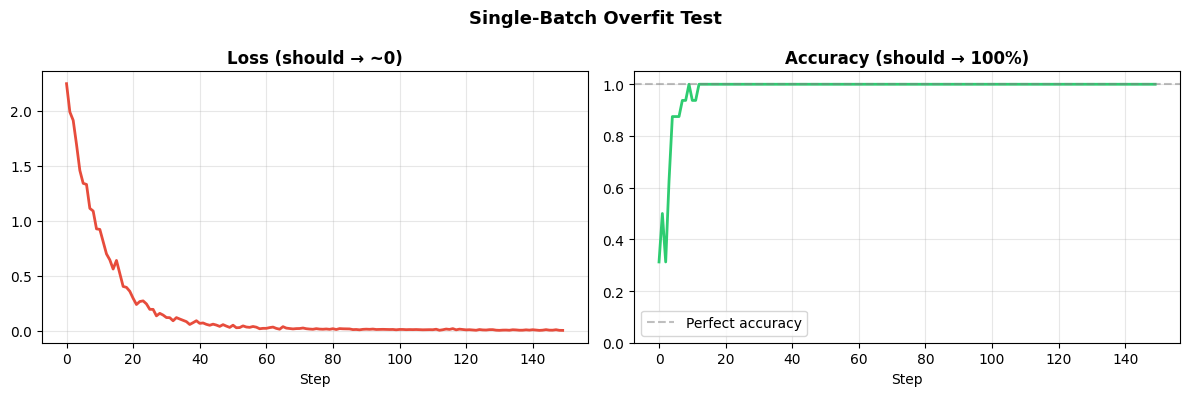


Result: ✓ PASSED
Final loss: 0.005323 | Final accuracy: 1.0000


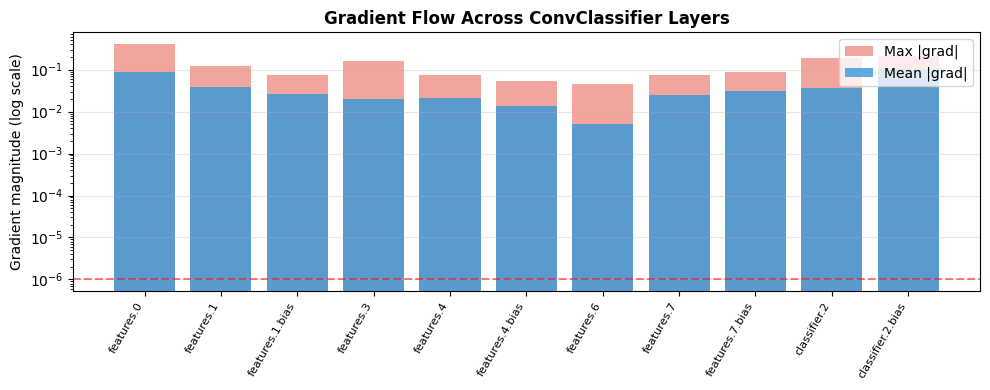

In [10]:
# =============================================================================
# MODULE 6: DIAGNOSTICS & PERFORMANCE TUNING
# =============================================================================

# ── 6A: Gradient Flow Diagnostics ────────────────────────────────────────────

def plot_grad_flow(model: nn.Module, title: str = "Gradient Flow"):
    """
    Visualize mean absolute gradient per layer.
    
    Dead layers: near-zero gradients → weights not learning
    Exploding:   extremely large values → instability
    Healthy:     relatively uniform, non-zero values across depth
    
    Call AFTER loss.backward() and BEFORE optimizer.step()
    """
    named_layers, mean_grads, max_grads = [], [], []

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            named_layers.append(name.replace('.weight', ''))
            mean_grads.append(param.grad.abs().mean().item())
            max_grads.append(param.grad.abs().max().item())

    fig, ax = plt.subplots(figsize=(max(10, len(named_layers) * 0.8), 4))
    x_pos = range(len(named_layers))
    ax.bar(x_pos, max_grads,  alpha=0.5, lw=1, color='#E74C3C', label='Max |grad|')
    ax.bar(x_pos, mean_grads, alpha=0.8, lw=1, color='#3498DB', label='Mean |grad|')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(named_layers, rotation=60, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('Gradient magnitude (log scale)')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='Dead threshold')
    plt.tight_layout()
    plt.show()


# ── 6B: Comprehensive Metrics Tracker ─────────────────────────────────────────

class MetricsTracker:
    """
    Tracks running metrics without storing full prediction arrays.
    Uses online (streaming) computation — memory O(1) w.r.t. dataset size.
    """
    def __init__(self, num_classes: int):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.total_loss = 0.0
        self.n_batches  = 0
        # Confusion matrix accumulator
        self.conf_matrix = torch.zeros(self.num_classes, self.num_classes, dtype=torch.long)

    def update(self, loss: float, logits: torch.Tensor, targets: torch.Tensor):
        self.total_loss += loss
        self.n_batches  += 1
        preds = logits.argmax(dim=1).cpu()
        targets_cpu = targets.cpu()
        # Accumulate confusion matrix
        for t, p in zip(targets_cpu, preds):
            self.conf_matrix[t.item(), p.item()] += 1

    def compute(self) -> Dict[str, float]:
        """Compute all metrics from accumulated state."""
        cm = self.conf_matrix.float()
        # Per-class TP, FP, FN
        tp = cm.diag()
        fp = cm.sum(dim=0) - tp   # column sum minus diagonal
        fn = cm.sum(dim=1) - tp   # row sum minus diagonal

        # Macro-averaged metrics (equal weight per class — good for imbalance)
        precision = (tp / (tp + fp + 1e-8)).mean().item()
        recall    = (tp / (tp + fn + 1e-8)).mean().item()
        f1        = 2 * precision * recall / (precision + recall + 1e-8)
        accuracy  = tp.sum().item() / cm.sum().item()

        return {
            'loss':      self.total_loss / max(1, self.n_batches),
            'accuracy':  accuracy,
            'precision': precision,
            'recall':    recall,
            'f1':        f1,
        }

    def plot_confusion_matrix(self, class_names: Optional[List[str]] = None):
        cm = self.conf_matrix.numpy().astype(float)
        # Row-normalize to show percentages
        cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax)
        if class_names:
            ax.set_xticks(range(len(class_names)))
            ax.set_yticks(range(len(class_names)))
            ax.set_xticklabels(class_names, rotation=45, ha='right')
            ax.set_yticklabels(class_names)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title('Normalized Confusion Matrix', fontweight='bold')
        plt.tight_layout()
        plt.show()


# ── 6C: Overfitting Diagnostic — Single Batch Test ───────────────────────────

def single_batch_overfit_test(
    model: nn.Module,
    criterion: nn.Module,
    optimizer_cls=optim.Adam,
    n_steps: int = 200,
    batch_size: int = 16,
    input_shape: Tuple = (3, 32, 32),
    num_classes: int = 10,
) -> Dict[str, List[float]]:
    """
    Sanity check: Can the model overfit a single batch?
    
    If loss does NOT converge to near-zero: architecture bug, vanishing gradient,
    wrong loss for the task, or input/label mismatch.
    """
    model = model.to(DEVICE).train()
    opt   = optimizer_cls(model.parameters(), lr=1e-3)

    # Fix a single batch — the model must memorize exactly these N samples
    x_fixed = torch.randn(batch_size, *input_shape, device=DEVICE)
    y_fixed = torch.randint(0, num_classes, (batch_size,), device=DEVICE)

    losses, accs = [], []
    for step in range(n_steps):
        opt.zero_grad(set_to_none=True)
        logits = model(x_fixed)
        loss   = criterion(logits, y_fixed)
        loss.backward()
        opt.step()

        acc = (logits.argmax(1) == y_fixed).float().mean().item()
        losses.append(loss.item())
        accs.append(acc)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(losses, color='#E74C3C', lw=2)
    ax1.set_title('Loss (should → ~0)', fontweight='bold')
    ax1.set_xlabel('Step')
    ax1.grid(True, alpha=0.3)

    ax2.plot(accs, color='#2ECC71', lw=2)
    ax2.axhline(1.0, color='gray', ls='--', alpha=0.5, label='Perfect accuracy')
    ax2.set_title('Accuracy (should → 100%)', fontweight='bold')
    ax2.set_xlabel('Step')
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Single-Batch Overfit Test', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    final_loss = losses[-1]
    final_acc  = accs[-1]
    status = '✓ PASSED' if final_acc > 0.99 else '✗ FAILED — check architecture/optimizer'
    print(f"\nResult: {status}")
    print(f"Final loss: {final_loss:.6f} | Final accuracy: {final_acc:.4f}")

    return {'losses': losses, 'accs': accs}


# Run diagnostics
model_diag = ConvClassifier(num_classes=10)
criterion_diag = nn.CrossEntropyLoss()

print("=" * 50)
print("DIAGNOSTIC: Single-Batch Overfit Test")
print("=" * 50)
results = single_batch_overfit_test(model_diag, criterion_diag, n_steps=150)

# Gradient flow after a forward pass
x_diag = torch.randn(4, 3, 32, 32, device=DEVICE)
y_diag = torch.randint(0, 10, (4,), device=DEVICE)
logits_diag = model_diag.to(DEVICE)(x_diag)
loss_diag   = criterion_diag(logits_diag, y_diag)
loss_diag.backward()
plot_grad_flow(model_diag, title="Gradient Flow Across ConvClassifier Layers")

## 6.2 Engineering Best Practices — Module 6

| Issue | Detection | Fix |
|-------|----------|-----|
| **Silent NaN propagation** | Loss stays non-NaN but accuracy is random | Add `assert not torch.isnan(loss)` in training loop; check inputs with `torch.isfinite()` |
| **Metric on wrong subset** | Validation accuracy equals training accuracy | Confirm loaders are different objects; log sample count per split |
| **Overfit before expected** | Val loss diverges within 1-2 epochs | Check data augmentation is applied to train only; confirm `is_train=True` for train loader |
| **Learning plateaus** | Loss stops decreasing despite good gradients | Reduce LR by 10x; run LR finder (cyclical LR scan) |
| **Class imbalance ignored** | F1 and precision/recall reveal poor minority class performance | Use class-weighted loss: `nn.CrossEntropyLoss(weight=class_weights)` |

---

# Module 7: Advanced Learning Paradigms

> *"The most powerful regularizer is not dropout or weight decay — it is the knowledge encoded in a pretrained model."*

---

## 7.1 Theoretical Breakdown

### Transfer Learning

A neural network trained on a large dataset (e.g., ImageNet with 1.2M images, 1000 classes) learns a hierarchical feature hierarchy:
- **Early layers**: edges, colors, textures (universal, transferable to ANY visual task)
- **Middle layers**: shapes, object parts (partially task-specific)
- **Final layers**: class-specific discriminators (task-specific, must be replaced)

**Feature Extraction**: Freeze all pretrained layers. Only train the new task-specific head. Use when: target dataset is small (< 1000 samples), or target domain is similar to pretraining domain.

**Fine-Tuning**: Initialize from pretrained weights, train *all* layers (usually with a much smaller LR for the backbone). Use when: target dataset is larger, or domain is different.

**Discriminative Learning Rates**: A key fine-tuning strategy — assign progressively smaller LRs to earlier layers:
$$\eta_l = \eta_{base} \cdot \alpha^{L - l}$$

Earlier layers have more universal features that should change less. Later layers are more task-specific and can tolerate larger updates.

### Unsupervised Pretraining

When labeled data is scarce but unlabeled data is abundant, we can pretrain a representation without labels.

**Masked Autoencoder (MAE)**: Randomly mask a large fraction (75%) of input patches. Train the encoder to reconstruct the masked patches. The reconstruction signal forces the encoder to learn rich semantic representations.

**Contrastive Self-Supervised Learning (SimCLR, MoCo)**:  
Apply two different random augmentations to the same image to get $(\mathbf{x}_i, \mathbf{x}_j)$ — a **positive pair**. All other images form **negative pairs**. Train the encoder to produce similar representations for positives and dissimilar for negatives (via InfoNCE loss).

### Pretraining with Auxiliary Tasks

Auxiliary tasks are secondary objectives trained jointly with the main task, providing additional learning signal:
$$\mathcal{L}_{total} = \mathcal{L}_{main} + \sum_k \lambda_k \mathcal{L}_{aux}^{(k)}$$

Examples:
- **Image classification + rotation prediction**: The rotation head forces the model to understand spatial orientation
- **Translation + language modeling**: Auxiliary MLM objective improves encoder representations  
- **Object detection + depth estimation**: Shared backbone benefits from multi-task signal

In [11]:
# =============================================================================
# MODULE 7: ADVANCED LEARNING PARADIGMS
# =============================================================================

# ── 7A: Transfer Learning — Feature Extraction vs Fine-Tuning ────────────────

class TransferLearningManager:
    """
    Manages the transition from feature extraction to progressive fine-tuning.
    
    Recommended training protocol:
      Phase 1 (10 epochs): Freeze backbone, train head only.
                           Reason: Randomly initialized head has large gradients
                           that would corrupt pretrained backbone features.
      Phase 2 (20+ epochs): Unfreeze backbone, fine-tune with LR decay by layer.
    """
    def __init__(self, model: nn.Module):
        self.model = model

    def freeze_backbone(self, backbone_attr: str = 'features'):
        """Phase 1: Only train the classification head."""
        backbone = getattr(self.model, backbone_attr)
        for param in backbone.parameters():
            param.requires_grad = False
        frozen = sum(p.numel() for p in backbone.parameters())
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"[Phase 1] Frozen: {frozen:,} | Trainable: {trainable:,} params")

    def unfreeze_backbone(self, backbone_attr: str = 'features'):
        """Phase 2: Unlock backbone for fine-tuning."""
        backbone = getattr(self.model, backbone_attr)
        for param in backbone.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"[Phase 2] Trainable: {trainable:,} params (all unfrozen)")

    def build_discriminative_optimizer(
        self,
        backbone_attr: str,
        head_attr: str,
        base_lr: float,
        lr_decay: float = 0.1,
    ) -> optim.AdamW:
        """
        Discriminative learning rates:
          backbone: base_lr * lr_decay  (smaller — preserve generic features)
          head:     base_lr             (larger  — learn task-specific features)
        """
        backbone = getattr(self.model, backbone_attr)
        head     = getattr(self.model, head_attr)

        param_groups = [
            {'params': backbone.parameters(), 'lr': base_lr * lr_decay,
             'name': 'backbone'},
            {'params': head.parameters(),     'lr': base_lr,
             'name': 'head'},
        ]
        print(f"Backbone LR: {base_lr * lr_decay:.2e} | Head LR: {base_lr:.2e}")
        return optim.AdamW(param_groups, weight_decay=1e-4)


# Demo
model_tl = ConvClassifier(num_classes=5)  # Adapting to 5-class task
manager  = TransferLearningManager(model_tl)

print("=== Transfer Learning Protocol ===")
manager.freeze_backbone()
manager.unfreeze_backbone()
opt_discrim = manager.build_discriminative_optimizer('features', 'classifier', base_lr=1e-3, lr_decay=0.1)


# ── 7B: Self-Supervised Contrastive Pretraining (SimCLR-style) ────────────────

class ProjectionHead(nn.Module):
    """
    MLP projection head for contrastive learning.
    
    Key finding (Chen et al., 2020): Applying the contrastive loss on a
    non-linear projection (rather than directly on the encoder output)
    improves representation quality by 10+ accuracy points on downstream tasks.
    
    The projection head is DISCARDED after pretraining — only the encoder
    representations are transferred.
    """
    def __init__(self, in_dim: int, hidden_dim: int = 256, out_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),  # no activation after final BN
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SimCLREncoder(nn.Module):
    """
    SimCLR-style self-supervised encoder.
    
    During pretraining:
      - Two augmented views of each image → encoder → projection head → NT-Xent loss
    
    After pretraining:
      - Discard projection head
      - Attach a linear classifier to encoder output
      - Fine-tune with labeled data (linear probe or full fine-tune)
    """
    def __init__(self, encoder_dim: int = 128, proj_dim: int = 64):
        super().__init__()
        # Encoder: learns representations
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
            nn.Linear(64, encoder_dim),
        )
        # Projection head: maps to contrastive embedding space
        self.projector = ProjectionHead(encoder_dim, hidden_dim=encoder_dim*2, out_dim=proj_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)                  # representation (used for downstream tasks)
        z = self.projector(h)                # projection (used for contrastive loss only)
        return h, z

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Inference-time: only need encoder representations."""
        return self.encoder(x)


def simclr_train_step(
    model: SimCLREncoder,
    x: torch.Tensor,
    temperature: float = 0.07,
) -> torch.Tensor:
    """
    One SimCLR training step.
    x: single batch (B, C, H, W) — will be augmented twice to create pairs.
    In practice, augmentation is applied by the DataLoader transform.
    """
    # Simulate two augmented views (in practice: actual augmentation pipeline)
    noise1 = torch.randn_like(x) * 0.1
    noise2 = torch.randn_like(x) * 0.1
    x1, x2 = x + noise1, x + noise2

    _, z1 = model(x1)
    _, z2 = model(x2)

    # NT-Xent loss (Normalized Temperature-scaled Cross-Entropy)
    contrastive = LossFunctionGallery.contrastive_loss(temperature=temperature)
    return contrastive(z1, z2)


# ── 7C: Multi-Task Learning with Auxiliary Objectives ─────────────────────────

class MultiTaskModel(nn.Module):
    """
    Multi-task model with:
      - Primary task:   Image classification
      - Auxiliary task: Rotation prediction (0°, 90°, 180°, 270°)
    
    The auxiliary rotation task forces the backbone to understand
    spatial structure — beneficial for the main classification objective.
    This serves as a form of self-supervised pretraining signal.
    """
    def __init__(self, num_classes: int = 10, aux_classes: int = 4):
        super().__init__()
        # Shared backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        )
        # Task-specific heads
        self.main_head = nn.Linear(128, num_classes)       # Primary objective
        self.aux_head  = nn.Linear(128, aux_classes)       # Auxiliary: rotation

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.backbone(x)
        return {
            'main': self.main_head(features),
            'aux':  self.aux_head(features),
        }


def multi_task_loss(
    outputs: Dict[str, torch.Tensor],
    main_labels: torch.Tensor,
    aux_labels: torch.Tensor,
    aux_weight: float = 0.3,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """
    Combined multi-task loss.
    
    aux_weight: λ in L_total = L_main + λ * L_aux
    Setting λ too high: auxiliary task dominates, hurts main task.
    Setting λ too low: auxiliary signal too weak to benefit backbone.
    Typical range: 0.1 - 0.5. Tune on validation set.
    """
    main_loss = F.cross_entropy(outputs['main'], main_labels)
    aux_loss  = F.cross_entropy(outputs['aux'],  aux_labels)
    total     = main_loss + aux_weight * aux_loss
    return total, {
        'total': total.item(),
        'main':  main_loss.item(),
        'aux':   aux_loss.item(),
    }


def generate_rotation_labels(x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Create rotation auxiliary task data.
    Randomly rotate each image by 0°/90°/180°/270° and return the rotation class.
    """
    B = x.size(0)
    rotation_labels = torch.randint(0, 4, (B,))
    x_rotated = torch.stack([
        torch.rot90(x[i], k=rotation_labels[i].item(), dims=[-2, -1])
        for i in range(B)
    ])
    return x_rotated, rotation_labels


# Demo multi-task training step
model_mt = MultiTaskModel(num_classes=10, aux_classes=4).to(DEVICE)
opt_mt   = optim.AdamW(model_mt.parameters(), lr=1e-3)

x_mt = torch.randn(16, 3, 32, 32, device=DEVICE)
y_main = torch.randint(0, 10, (16,), device=DEVICE)
x_rot, y_rot = generate_rotation_labels(x_mt.cpu())
x_rot, y_rot = x_rot.to(DEVICE), y_rot.to(DEVICE)

opt_mt.zero_grad(set_to_none=True)
outputs = model_mt(x_rot)  # process rotated images
total_loss, loss_breakdown = multi_task_loss(outputs, y_main, y_rot, aux_weight=0.3)
total_loss.backward()
opt_mt.step()

print("=== Multi-Task Training Step ===")
for k, v in loss_breakdown.items():
    print(f"  {k:8s}: {v:.4f}")


# ── 7D: Knowledge Distillation ────────────────────────────────────────────────

class KnowledgeDistillationLoss(nn.Module):
    """
    Knowledge Distillation (Hinton et al., 2015).
    
    Train a small 'student' model to mimic a large 'teacher' model.
    The teacher's soft probability distributions (softmax outputs)
    encode richer inter-class relationship information than hard labels.
    
    L_KD = α * L_CE(student, hard_labels) 
         + (1-α) * T² * L_KL(student_soft, teacher_soft)
    
    T (temperature): Higher T = softer distributions = more information
                     transferred about dark knowledge (wrong class probs).
    α: Weight between hard-label loss and soft-label distillation loss.
    """
    def __init__(self, temperature: float = 4.0, alpha: float = 0.5):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha
        self.kl    = nn.KLDivLoss(reduction='batchmean', log_target=False)

    def forward(
        self,
        student_logits: torch.Tensor,
        teacher_logits: torch.Tensor,
        hard_labels:    torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        # Hard label loss (standard cross-entropy)
        ce_loss = F.cross_entropy(student_logits, hard_labels)

        # Soft label distillation loss
        # Temperature scaling softens the distributions
        student_soft = F.log_softmax(student_logits / self.T, dim=-1)
        teacher_soft = F.softmax(teacher_logits   / self.T, dim=-1)
        # T² factor corrects for the gradient magnitude after temperature scaling
        kd_loss = self.T**2 * self.kl(student_soft, teacher_soft)

        total = self.alpha * ce_loss + (1 - self.alpha) * kd_loss
        return total, {'ce': ce_loss.item(), 'kd': kd_loss.item(), 'total': total.item()}


# Demo: teacher vs student
B, C = 16, 10
teacher_logits = torch.randn(B, C) * 2  # typically more confident
student_logits = torch.randn(B, C)
hard_labels    = torch.randint(0, C, (B,))

kd_loss_fn = KnowledgeDistillationLoss(temperature=4.0, alpha=0.5)
total_kd_loss, kd_breakdown = kd_loss_fn(student_logits, teacher_logits, hard_labels)
print("\n=== Knowledge Distillation Loss ===")
for k, v in kd_breakdown.items():
    print(f"  {k:8s}: {v:.4f}")

=== Transfer Learning Protocol ===
[Phase 1] Frozen: 93,472 | Trainable: 645 params
[Phase 2] Trainable: 94,117 params (all unfrozen)
Backbone LR: 1.00e-04 | Head LR: 1.00e-03
=== Multi-Task Training Step ===
  total   : 2.7215
  main    : 2.3078
  aux     : 1.3787

=== Knowledge Distillation Loss ===
  ce      : 2.5159
  kd      : 2.0556
  total   : 2.2857


PRODUCTION TRAINING PIPELINE — Full Integration Demo
Parameters WITHOUT weight decay (7):
  features.1.weight
  features.1.bias
  features.4.weight
  features.4.bias
  features.7.weight
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
-----------------------------------------------------------------
     1 |     2.3550 |    0.1125 |   2.3065 |  0.0938 |   1.00e-03
  [EarlyStopping] Improved → 2.306497
     2 |     2.2715 |    0.1437 |   2.3145 |  0.1094 |   9.50e-04
  [EarlyStopping] No improvement (1/5)
     3 |     2.1198 |    0.3156 |   2.3295 |  0.1094 |   8.12e-04
  [EarlyStopping] No improvement (2/5)
     4 |     2.0391 |    0.4188 |   2.3464 |  0.0859 |   6.11e-04
  [EarlyStopping] No improvement (3/5)
     5 |     1.9701 |    0.4969 |   2.3519 |  0.0859 |   3.89e-04
  [EarlyStopping] No improvement (4/5)
     6 |     1.9393 |    0.5437 |   2.3540 |  0.0859 |   1.88e-04
  [EarlyStopping] No improvement (5/5)

Early stopping triggered at epoch 6.
  [EarlyStoppin

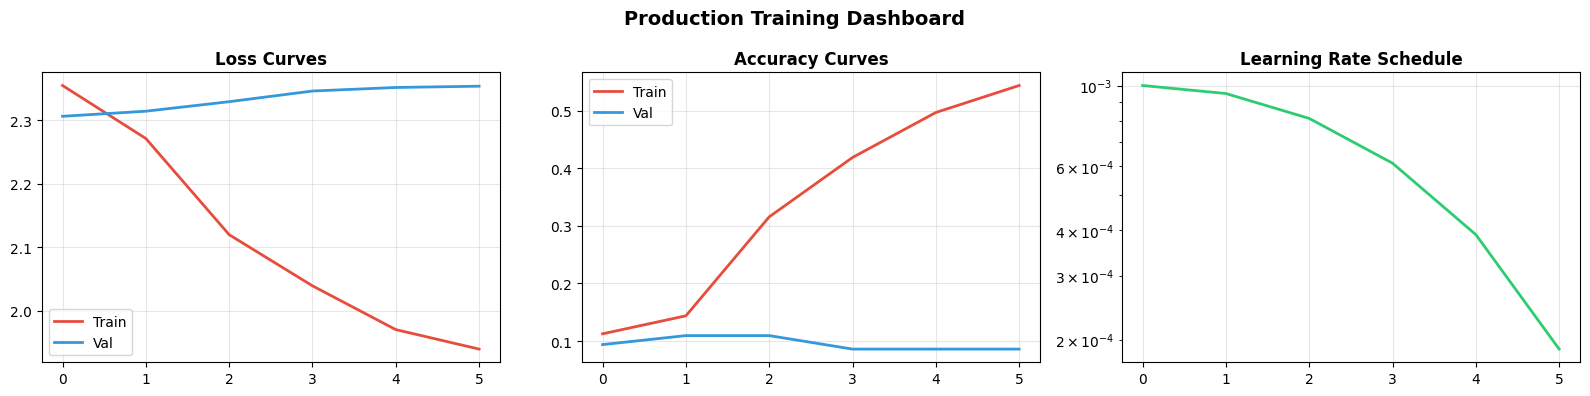


✓ Full pipeline complete.


In [12]:
# ── 7E: Putting It All Together — Complete Training Pipeline ──────────────────

@dataclass
class FullPipelineConfig:
    """Production training configuration — single source of truth."""
    # Data
    num_classes:     int   = 10
    img_size:        int   = 32
    # Training
    batch_size:      int   = 32
    num_epochs:      int   = 30
    base_lr:         float = 1e-3
    weight_decay:    float = 1e-4
    # Regularization
    dropout_rate:    float = 0.2
    label_smoothing: float = 0.1
    grad_clip:       float = 1.0
    # Multi-task
    aux_weight:      float = 0.2
    # Transfer
    pretrain_epochs: int   = 10  # freeze backbone for this many epochs
    # LR Schedule
    warmup_epochs:   int   = 3
    min_lr_ratio:    float = 0.1
    # Early stopping
    patience:        int   = 10


class ProductionTrainer:
    """
    End-to-end trainer incorporating all modules:
      ✓ Gradient clipping (Module 4)
      ✓ AMP mixed precision (Module 3)
      ✓ Warmup + Cosine LR schedule (Module 4)
      ✓ Early stopping + model checkpointing (Module 5)
      ✓ Comprehensive metrics (Module 6)
      ✓ Multi-task loss (Module 7)
    """
    def __init__(self, model: nn.Module, cfg: FullPipelineConfig, device: torch.device):
        self.model  = model.to(device)
        self.cfg    = cfg
        self.device = device

        self.criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
        self.optimizer = build_optimizer_with_param_groups(
            model, lr=cfg.base_lr, weight_decay=cfg.weight_decay
        )
        self.scaler      = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
        self.early_stop  = EarlyStopping(patience=cfg.patience, mode='min')
        self.history     = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    def setup_scheduler(self, steps_per_epoch: int):
        total_steps  = self.cfg.num_epochs  * steps_per_epoch
        warmup_steps = self.cfg.warmup_epochs * steps_per_epoch
        self.scheduler = WarmupCosineScheduler(
            self.optimizer, warmup_steps, total_steps, self.cfg.min_lr_ratio
        )

    def train_epoch(self, loader: DataLoader) -> Tuple[float, float]:
        self.model.train()
        tracker = MetricsTracker(self.cfg.num_classes)

        for x, y in loader:
            x, y = x.to(self.device, non_blocking=True), y.to(self.device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=(self.device.type == 'cuda')):
                logits = self.model(x)
                loss   = self.criterion(logits, y)

            self.optimizer.zero_grad(set_to_none=True)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            self.scheduler.step()  # step-level scheduling

            tracker.update(loss.item(), logits.detach(), y)

        metrics = tracker.compute()
        return metrics['loss'], metrics['accuracy']

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        self.model.eval()
        tracker = MetricsTracker(self.cfg.num_classes)

        for x, y in loader:
            x, y = x.to(self.device, non_blocking=True), y.to(self.device, non_blocking=True)
            logits = self.model(x)
            loss   = self.criterion(logits, y)
            tracker.update(loss.item(), logits, y)

        metrics = tracker.compute()
        return metrics['loss'], metrics['accuracy']

    def fit(self, train_loader: DataLoader, val_loader: DataLoader):
        self.setup_scheduler(steps_per_epoch=len(train_loader))
        print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10}")
        print("-" * 65)

        for epoch in range(1, self.cfg.num_epochs + 1):
            t_loss, t_acc = self.train_epoch(train_loader)
            v_loss, v_acc = self.evaluate(val_loader)
            current_lr    = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['val_loss'].append(v_loss)
            self.history['train_acc'].append(t_acc)
            self.history['val_acc'].append(v_acc)
            self.history['lr'].append(current_lr)

            print(f"{epoch:>6} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>7.4f} | {current_lr:>10.2e}")

            self.early_stop.step(v_loss, self.model)
            if self.early_stop.should_stop:
                print(f"\nEarly stopping triggered at epoch {epoch}.")
                break

        self.early_stop.restore_best_weights(self.model)
        return self

    def plot_training_curves(self):
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].plot(self.history['train_loss'], label='Train', color='#E74C3C', lw=2)
        axes[0].plot(self.history['val_loss'],   label='Val',   color='#3498DB', lw=2)
        axes[0].set_title('Loss Curves', fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.history['train_acc'], label='Train', color='#E74C3C', lw=2)
        axes[1].plot(self.history['val_acc'],   label='Val',   color='#3498DB', lw=2)
        axes[1].set_title('Accuracy Curves', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(self.history['lr'], color='#2ECC71', lw=2)
        axes[2].set_title('Learning Rate Schedule', fontweight='bold')
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)

        plt.suptitle('Production Training Dashboard', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


# Full pipeline demo
print("=" * 65)
print("PRODUCTION TRAINING PIPELINE — Full Integration Demo")
print("=" * 65)

prod_cfg   = FullPipelineConfig(num_epochs=8, batch_size=32, warmup_epochs=1, patience=5)
prod_model = ConvClassifier(num_classes=10)
prod_trainer = ProductionTrainer(prod_model, prod_cfg, DEVICE)
prod_trainer.fit(synth_train, synth_val)
prod_trainer.plot_training_curves()

print("\n✓ Full pipeline complete.")

## 7.2 Engineering Best Practices — Module 7

| Issue | Root Cause | Fix |
|-------|-----------|-----|
| **Catastrophic forgetting** | Fine-tuning with large LR destroys pretrained features | Use discriminative LRs; unfreeze gradually layer by layer |
| **Feature extraction misfit** | Pretrained backbone feature distribution ≠ target domain | Fine-tune at least the last few backbone blocks |
| **Aux task hurts performance** | Auxiliary gradient interferes with main objective | Reduce `aux_weight`; use gradient surgery (project conflicting gradients) |
| **Contrastive collapse** | All representations collapse to the same point | Ensure sufficient batch size (≥ 256); use a memory bank (MoCo) for small batches |
| **KD temperature too high** | Teacher distribution becomes uniform — no signal | Keep T in [2, 6]; validate with calibration analysis |

---

# Course Summary: The Engineering Mental Model

The following framework captures the *sequence of decisions* for any neural network training project:

```
1. DATA PIPELINE
   ├── Verify Dataset.__getitem__ correctness
   ├── Benchmark DataLoader throughput (GPU utilization > 85%?)
   └── Implement augmentation, normalization, splits

2. ARCHITECTURE
   ├── Choose activation (GELU for transformers, ReLU/GELU for CNNs)
   ├── Choose normalization (BN for CNNs, LN for Transformers/small batches)
   ├── Apply Kaiming init for conv layers
   └── Verify shapes: print output of each module

3. SANITY CHECKS (before full training)
   ├── single_batch_overfit_test() → must reach ~100% accuracy
   ├── plot_grad_flow() → no dead/exploding layers
   └── loss at init == -log(1/num_classes) for classification

4. TRAINING ENGINE
   ├── Loss: CrossEntropyLoss (raw logits), Focal (imbalance), Dice (segmentation)
   ├── Optimizer: AdamW with param groups (no WD on BN/bias)
   ├── AMP: GradScaler for fp16 on CUDA
   └── Loop: train() → forward → backward → clip → step → eval() → log

5. OPTIMIZATION
   ├── Schedule: Warmup (1-5% of total steps) + Cosine decay
   ├── Gradient clipping: norm ≤ 1.0 (transformers), ≤ 5.0 (RNNs)
   └── Monitor: LR, grad norm, loss, val metrics each epoch

6. REGULARIZATION
   ├── Start with weight_decay=1e-4, dropout=0.1-0.3
   ├── Add stochastic depth for deep networks (>20 layers)
   ├── Add MixUp/CutMix for image classification
   └── Early stopping: patience=10-20 epochs

7. DIAGNOSTICS
   ├── If train >> val: reduce model size or increase regularization
   ├── If train ≈ val (both bad): increase model size or LR
   ├── If loss NaN: check inputs, reduce LR, add gradient clipping
   └── Use confusion matrix for class-level diagnosis

8. SCALING
   ├── Transfer from pretrained backbone → freeze → fine-tune
   ├── Multi-task auxiliary objectives
   └── Self-supervised pretraining on unlabeled data
```

---

## Reference Table: PyTorch Decision Guide

| Scenario | Recommended Approach |
|----------|---------------------|
| **Image classification, ≥ 10K samples** | ResNet/EfficientNet backbone, AdamW, Cosine LR, MixUp |
| **Image classification, < 1K samples** | Frozen pretrained backbone + linear probe, strong augmentation |
| **Text classification/generation** | Pretrained transformer, AdamW, linear warmup, LayerNorm |
| **Class imbalance** | Focal loss or class-weighted CE, oversample minority class |
| **Small batch (< 16)** | LayerNorm or GroupNorm instead of BatchNorm |
| **Very deep network (> 50 layers)** | Residual connections, stochastic depth, gradient clipping |
| **Unlabeled data available** | SimCLR/MAE pretraining, then supervised fine-tuning |
| **Small student model needed** | Knowledge distillation from large teacher |

---

**End of Course: Advanced Neural Network Engineering with PyTorch**  
*Authored for advanced AI practitioners who need to build, not just use.*